# Fixed-point arithmetic

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$This notebook studies how to implement the Metropolis-Hastings acceptance rule in fixed-point arithmetic.

Ideally, we want to sample from a distribution $q_t = P^t q_0$ such that $\|q_t-\pi\|_\mathrm{TV}\le \varepsilon$. In practice, because of finite-precision arithmetic, we implement an approximate transition matrix $\tilde P$ instead of the exact transition matrix $P$. If $\tilde\pi$ denotes the stationary distribution of $\tilde P$, the resulting error can be decomposed as

$$
\|(\tilde P)^t q_0-\pi\|_\mathrm{TV}
\le
\underbrace{\|(\tilde P)^t q_0-\tilde\pi\|_\mathrm{TV}}_{\text{mixing error}}
+
\underbrace{\|\tilde\pi-\pi\|_\mathrm{TV}}_{\text{arithmetic error}}.
$$

This follows directly from the triangle inequality for total-variation distance. The point of this decomposition is that the arithmetic error is controlled through the stationary distribution of the approximate chain, rather than by accumulating a per-step error over the full number of steps $t$, which may be very large.

The arithmetic approximation has two main sources of error:

* the fixed-point summation of Hamiltonian terms used to compute the energy difference between the current and proposed states, where the error comes from discretizing the coefficients;
* the fixed-point approximation of the exponential function appearing in the acceptance rule.

To obtain a target total-variation error $\varepsilon$, we budget the arithmetic error to be a negligible fraction of the allowed error and set

$$
\varepsilon_\mathrm{arith} = \frac{\varepsilon}{50}.
$$

We then split this arithmetic budget as follows:

* $\varepsilon_\mathrm{discr} = \varepsilon_\mathrm{arith}/2$ for discretizing the Ising coefficients;
* $\varepsilon_\mathrm{op} = \varepsilon_\mathrm{arith}/2$ for the error allowed in the nonlinear arithmetic.

**Table of contents**

1. Import
2. Upper bound on the energy difference
3. Discretization error
4. Operation error
5. Cutoff approximation

## Import

In [1]:
import sys
if ".." not in sys.path:
    sys.path.append("..")  # allows us to import the local package without installing it in editable mode

import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np
from numpy.polynomial.chebyshev import chebval
from scipy.special import ive

## Upper bound on the energy difference

We start by determining a safe upper bound $\alpha$ on the energy difference and on any partial sum of terms contributing to the energy difference.

Recall that in `1_sherrington_kirkpatrick.ipynb` we showed that the 1-norm of the SK coefficients scales as $\frac{1}{\sqrt{\pi}}n^{3/2}$. We could instead consider the operator norm, but since we want a safe upper bound that also captures outliers, we stick to the 1-norm. Therefore, the energy difference is bounded by twice that quantity, and we set
$$\alpha = 2 \left(\sum_{i<j} |J_{ij}| + \sum_i |h_i|\right) \sim \frac{2}{\sqrt{\pi}} n^{3/2}.$$

## Discretization error

Let $m = n + \binom{n}{2}$ be the number of terms contributing to the energy difference in the worst-case scenario, corresponding to dense, non-local moves such as the uniform move. Consider the normalized Hamiltonian $\hat{H}=H/\alpha$, where all coefficients $\hat h_i,\hat J_{ij}$ are normalized by $\alpha$ so that both the coefficients and the energy difference fit into a signed fixed-point register with a single integer bit and $F$ fractional bits.

Using $F$ fractional bits introduces an error in the energy calculation bounded by

$$
|\alpha\hat{H}(x) - H(x)| \le m \alpha 2^{-F} \le \varepsilon_\text{discr}.
$$

Therefore, it is sufficient to choose

$$
F \ge
\left\lceil \log_2\left(\frac{m \alpha}{\varepsilon_\text{discr}}\right) \right\rceil
\approx
\left\lceil \frac{7}{2} \log_2\left(\pi^{-1/7} n\right) + \log_2(\varepsilon_\text{discr}^{-1}) \right\rceil
\approx
\left\lceil \frac{7}{2} \log_2(n) + \log_2(\varepsilon_\text{discr}^{-1}) \right\rceil.
$$

We can examine the expected value of $F$ as the system size grows up to $100$ spins, using a discretization error $\varepsilon_\text{discr}=10^{-4}$. This corresponds to an appropriate portion of the error budget for a target total-variation error of $10^{-2}$.

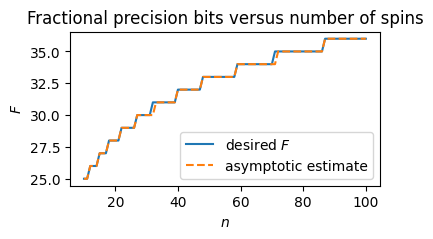

In [2]:
eps_discr = 1e-4

def fractional_bits(n, eps):
    m = n * (n + 1) / 2
    alpha = (2 / np.sqrt(np.pi)) * n**1.5
    return np.ceil(np.log2(m * alpha / eps))

def approx_fractional_bits(n, eps):
    return np.ceil(3.5 * np.log2((np.pi**(-1/7)) * n) - np.log2(eps))

ns = np.arange(10, 101)
plt.figure(figsize=(4, 2))
plt.plot(ns, [fractional_bits(n, eps_discr) for n in ns], label="desired $F$")
plt.plot(ns, [approx_fractional_bits(n, eps_discr) for n in ns], linestyle="--", label=r"asymptotic estimate")
plt.title("Fractional precision bits versus number of spins")
plt.xlabel(r"$n$")
plt.ylabel(r"$F$")
plt.legend()
plt.show()

### Operation error

The operation error comes from implementing the function
$$g(x)=\exp(-\beta\alpha x),$$
where $x=\frac{\Delta E}{\alpha}\in[0,1]$ is the normalized positive energy difference.

Let $\lambda = \beta \alpha$. We approximate $g$ by a degree-$d$ Chebyshev polynomial $p_d$ only on the positive branch $[0,1]$; however, it is convenient to map the domain back to $[-1, 1]$ via the transformation $t = 2x-1$, such that $g(x) = e^{-\lambda x} = e^{-\frac{\lambda}{2}} e^{-\frac{\lambda}{2}t}$. For $z = \lambda/2$, we have the known Chebyshev expansion
$$
g(x) = e^{-\lambda x} = e^{-z} \left[I_0(z) + 2\sum_{k = 1}^\infty (-1)^k I_k(z)T_k(t)\right].
$$

The truncation error is therefore controlled by the tail of the coefficients $2e^{-z}I_k(z)$. These coefficients have two useful decay regimes:

* **Factorial regime**, roughly when $z \lesssim 2\log(1/\varepsilon_{\mathrm{op}})$. In this regime, the degree needed to reach the target error lies in the far tail of the Bessel coefficients, where the decay is close to factorial. A conservative choice is then $d=O(\log(1/\varepsilon_{\mathrm{op}}))$. This bound is safe but can be pessimistic.

* **Gaussian regime**, roughly when $z$ is large enough that the relevant coefficients satisfy $k\ll z$. In this regime, $2e^{-z}I_k(z)$ decays approximately like a Gaussian in $k/\sqrt{z}$, so the required degree scales as $d\sim\sqrt{z\log(1/\varepsilon_{\mathrm{op}})}=\sqrt{\frac{\lambda}{2}\log(1/\varepsilon_{\mathrm{op}})}$. Equivalently, up to constants, $d=O(\sqrt{\lambda\log(1/\varepsilon_{\mathrm{op}})})$.

In practice, the transition between the two regimes is not sharp. We can test the decay of the coefficients with the following code. A conservative heuristic bound for the untruncated positive branch is
$$d \sim \sqrt{\beta\alpha \log(\varepsilon_\mathrm{op}^{-1})} + \log(\varepsilon_\mathrm{op}^{-1}).$$

In [3]:
def compare_decay_regimes(lam: float = 1.0, max_k: int = 25, eps: float = 1e-16, dps: int = 120,) -> None:
    """Compare exact Chebyshev coefficient decay with factorial and Gaussian estimates."""
    mp.mp.dps = dps
    lam, eps = mp.mpf(lam), mp.mpf(eps)
    z = lam / 2

    # Exact Chebyshev coefficient and two asymptotic estimates.
    coeff = lambda k: 2 * mp.exp(-z) * mp.besseli(k, z)
    fact = lambda k: 2 * mp.exp(-z) * (z / 2)**k / mp.factorial(k)
    gauss = lambda k: 2 / mp.sqrt(2 * mp.pi * z) * mp.exp(-k**2 / (2 * z))
    fmt = lambda x: f"{float(mp.mpf(x)):.5e}"

    def tail(d: int) -> mp.mpf:
        """Return the Chebyshev tail after degree d."""
        s = mp.mpf(0)
        for k in range(d + 1, 100000):
            ck = coeff(k)
            s += ck
            if k > d + 20 and ck < eps * mp.mpf("1e-8"):
                break
        return s

    # Heuristic degree choices from the two decay regimes.
    d_fact = int(mp.ceil(2 * mp.log(2 / eps)))
    d_gauss = int(mp.ceil(mp.sqrt(lam * mp.log(1 / eps))))
    z_cut = 2 * mp.log(1 / eps)

    print(f"lam={fmt(lam)}  z={fmt(z)}  eps={fmt(eps)}")
    print("-" * 49)
    print(f"{'k':>2} | {'|ck|':>11} | {'fact':>11} | {'gauss':>11} | b")
    print("-" * 49)

    # Print which estimate is closer coefficient-by-coefficient.
    for k in range(1, max_k + 1):
        ck, fk, gk = coeff(k), fact(k), gauss(k)
        best = "fact" if abs(ck - fk) < abs(ck - gk) else "gauss"
        print(f"{k:2d} | {fmt(ck):>11} | {fmt(fk):>11} | {fmt(gk):>11} | {best}")

    print("-" * 49)
    regime = "gauss" if z > z_cut else "fact"
    sign = ">" if z > z_cut else "<="
    print(f"rule: z={fmt(z)} {sign} {fmt(z_cut)} -> {regime}")
    print("-" * 49)

    # Check whether each heuristic degree reaches the target tail error.
    for name, d in [("fact", d_fact), ("gauss", d_gauss)]:
        err = tail(d)
        stat = "ok" if err <= eps else "fail"
        print(f"{name:5s}: d={d:3d}, tail={fmt(err)} ({stat})")

compare_decay_regimes(lam=100.0, max_k=20, eps=1e-8)

lam=1.00000e+02  z=5.00000e+01  eps=1.00000e-08
-------------------------------------------------
 k |        |ck| |        fact |       gauss | b
-------------------------------------------------
 1 | 1.11986e-01 | 9.64375e-21 | 1.11715e-01 | gauss
 2 | 1.08644e-01 | 1.20547e-19 | 1.08413e-01 | gauss
 3 | 1.03295e-01 | 1.00456e-18 | 1.03126e-01 | gauss
 4 | 9.62484e-02 | 6.27848e-18 | 9.61541e-02 | gauss
 5 | 8.78950e-02 | 3.13924e-17 | 8.78783e-02 | gauss
 6 | 7.86694e-02 | 1.30802e-16 | 7.87243e-02 | gauss
 7 | 6.90143e-02 | 4.67149e-16 | 6.91275e-02 | gauss
 8 | 5.93454e-02 | 1.45984e-15 | 5.94986e-02 | gauss
 9 | 5.00238e-02 | 4.05511e-15 | 5.01969e-02 | gauss
10 | 4.13369e-02 | 1.01378e-14 | 4.15107e-02 | gauss
11 | 3.34891e-02 | 2.30404e-14 | 3.36480e-02 | gauss
12 | 2.66017e-02 | 4.80009e-14 | 2.67344e-02 | gauss
13 | 2.07202e-02 | 9.23094e-14 | 2.08208e-02 | gauss
14 | 1.58271e-02 | 1.64838e-13 | 1.58942e-02 | gauss
15 | 1.18570e-02 | 2.74730e-13 | 1.18930e-02 | gauss
16 | 8.7

Both the approximated function and the approximation error can be plotted explicitly:

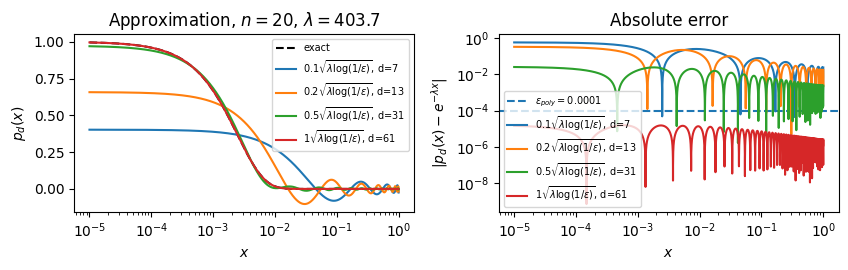

In [4]:
beta, eps_poly, n0 = 4, 1e-4, 20
fracs = [1/10, 1/5, 1/2, 1]

alpha = lambda n: 2 / np.sqrt(np.pi) * n**1.5  # Worst-case normalization estimate.

def approx(lam: float, d: int, x: np.ndarray) -> np.ndarray:
    """Return the degree-d Chebyshev truncation of exp(-lam*x) on [0, 1]."""
    k = np.arange(d + 1)                       # Chebyshev modes k = 0, ..., d.
    c = 2 * (-1)**k * ive(k, lam / 2)          # Coefficients 2(-1)^k exp(-lam/2) I_k(lam/2).
    c[0] /= 2                                  # The zeroth Chebyshev coefficient has no factor 2.
    return chebval(2 * x - 1, c)               # Evaluate in the shifted variable t = 2x - 1.

lam = beta * alpha(n0)
base_d = np.sqrt(lam * np.log(1 / eps_poly))   # Gaussian-regime degree scale.

x = np.geomspace(1e-5, 1, 8000)                # Log grid to resolve the boundary layer near x = 0.
g = np.exp(-lam * x)                           # Exact function values.

fig, ax = plt.subplots(1, 2, figsize=(8.5, 2.8))

ax[0].plot(x, g, "k--", label="exact")
ax[1].axhline(eps_poly, ls="--", label=fr"$\epsilon_{{poly}}={eps_poly}$")

for f in fracs:
    d = int(np.ceil(f * base_d))               # Test fractions of the expected degree scale.
    p = approx(lam, d, x)
    label = fr"${f:g}\sqrt{{\lambda\log(1/\epsilon)}}$, d={d}"
    ax[0].plot(x, p, label=label)
    ax[1].plot(x, np.abs(p - g), label=label)

for a in ax:
    a.set_xscale("log")
    a.set_xlabel(r"$x$")
    a.legend(fontsize=7)

ax[0].set(title=fr"Approximation, $n={n0}$, $\lambda={lam:.1f}$", ylabel=r"$p_d(x)$")
ax[1].set(title="Absolute error", ylabel=r"$|p_d(x)-e^{-\lambda x}|$", yscale="log")

plt.tight_layout()
plt.show()

## Cutoff approximation

We can instead approximate a truncated function that is easier to handle.

Split the operation-error budget as $\varepsilon_\text{op}=\varepsilon_\text{tail}+\varepsilon_\text{poly}$, for example half and half, and let $\tau=\log(\varepsilon_\text{tail}^{-1})$. When $\beta\alpha x>\tau$, the function satisfies $g(x)=e^{-\beta\alpha x}<\varepsilon_\text{tail}$, so it can be safely replaced by zero. Therefore, we approximate $g(x)$ by the cutoff function
$$
\widetilde g(x)=
\begin{cases}
e^{-\beta\alpha x}, & 0\le \beta\alpha x\le \tau,\\
0, & \beta\alpha x>\tau.
\end{cases}
$$
The tail error is then at most $\varepsilon_\text{tail}$. On the remaining interval, we make the change of variable $u=\beta\alpha x$, so the polynomial only has to approximate $e^{-u}$ on $u\in[0,\tau]$, rather than $e^{-\beta\alpha x}$ on the full interval $x\in[0,1]$. Since $\tau=\log(\varepsilon_\text{tail}^{-1})$, this removes the direct dependence on $\beta\alpha$ from the polynomial approximation problem whenever the cutoff is active. Numerically, we find that a degree proportional to
$$
d \sim \log_2(\varepsilon_\text{op}^{-1})
$$
is sufficient in the tested regime.

In [6]:
def compare_cutoff_approx(lam: float = 100.0, max_k: int = 25, eps: float = 1e-8, tail_frac: float = 0.5, dps: int = 120) -> None:
    """Compare the cutoff approximation error with the exact Chebyshev tail."""
    mp.mp.dps = dps
    lam, eps, tail_frac = mp.mpf(lam), mp.mpf(eps), mp.mpf(tail_frac)

    if not 0 < tail_frac < 1:
        raise ValueError("tail_frac must be between 0 and 1")

    eps_tail, eps_poly = tail_frac * eps, (1 - tail_frac) * eps
    tau = mp.log(1 / eps_tail)                 # Cutoff threshold: exp(-tau) = eps_tail.
    U = min(lam, tau)                          # Active interval length in u = lam*x.
    z = U / 2                                  # Chebyshev parameter after mapping [0, U] to [-1, 1].

    coeff = lambda k: 2 * mp.exp(-z) * mp.besseli(k, z)  # Exact Chebyshev coefficient magnitude.
    fmt = lambda x: f"{float(mp.mpf(x)):.5e}"             # Compact scientific notation.

    def tail(d: int) -> mp.mpf:
        """Return the Chebyshev tail after degree d."""
        s = mp.mpf(0)
        for k in range(d + 1, 100000):
            ck = coeff(k)
            s += ck
            if k > d + 20 and ck < eps_poly * mp.mpf("1e-8"):
                break
        return s

    def min_degree() -> int:
        """Return the smallest degree whose polynomial tail is below eps_poly."""
        d = 0
        while tail(d) > eps_poly:
            d += 1
        return d

    d_rule = int(mp.ceil(mp.log(1 / eps, 2)))  # Empirical logarithmic degree rule.
    d_min = min_degree()
    cutoff_err = eps_tail if lam > tau else mp.mpf(0)

    print(f"lam={fmt(lam)}  tau={fmt(tau)}  U={fmt(U)}  z={fmt(z)}")
    print(f"eps={fmt(eps)}  eps_tail={fmt(eps_tail)}  eps_poly={fmt(eps_poly)}")
    print("-" * 31)
    print(f"{'k':>2} | {'|c_k|':>11}")
    print("-" * 31)

    for k in range(1, max_k + 1):
        print(f"{k:2d} | {fmt(coeff(k)):>11}")

    print("-" * 31)
    print(f"cutoff tail <= {fmt(cutoff_err)}")
    print("-" * 31)

    for name, d in [("rule", d_rule), ("min", d_min)]:
        poly_err = tail(d)
        total_err = cutoff_err + poly_err
        stat = "ok" if total_err <= eps else "fail"
        print(f"{name:4s}: d={d:3d}, poly={fmt(poly_err)}, total={fmt(total_err)} ({stat})")

compare_cutoff_approx(lam=1000.0, max_k=20, eps=1e-4)

lam=1.00000e+03  tau=9.90349e+00  U=9.90349e+00  z=4.95174e+00
eps=1.00000e-04  eps_tail=5.00000e-05  eps_poly=5.00000e-05
-------------------------------
 k |       |c_k|
-------------------------------
 1 | 3.29228e-01
 2 | 2.36011e-01
 3 | 1.38579e-01
 4 | 6.80951e-02
 5 | 2.85652e-02
 6 | 1.04080e-02
 7 | 3.34249e-03
 8 | 9.57850e-04
 9 | 2.47498e-04
10 | 5.81743e-05
11 | 1.25331e-05
12 | 2.49109e-06
13 | 4.59388e-07
14 | 7.89922e-08
15 | 1.27204e-08
16 | 1.92582e-09
17 | 2.75061e-10
18 | 3.71783e-11
19 | 4.76883e-12
20 | 5.81967e-13
-------------------------------
cutoff tail <= 5.00000e-05
-------------------------------
rule: d= 14, poly=1.49639e-08, total=5.00150e-05 (ok)
min : d= 10, poly=1.55776e-05, total=6.55776e-05 (ok)


For the target total-variation error $\varepsilon=10^{-2}$ used here, the budget above gives $\varepsilon_\mathrm{op}=10^{-4}$. With the explicit cutoff construction, the polynomial degree is controlled by $\varepsilon_\mathrm{op}$ through $\tau=\log(\varepsilon_\mathrm{tail}^{-1})$, not directly by $\beta$, $\alpha$, or $n$, whenever $\lambda=\beta\alpha$ is larger than the cutoff scale. In this regime, degree $d=12$ is sufficient to achieve an operation error below the allocated budget.

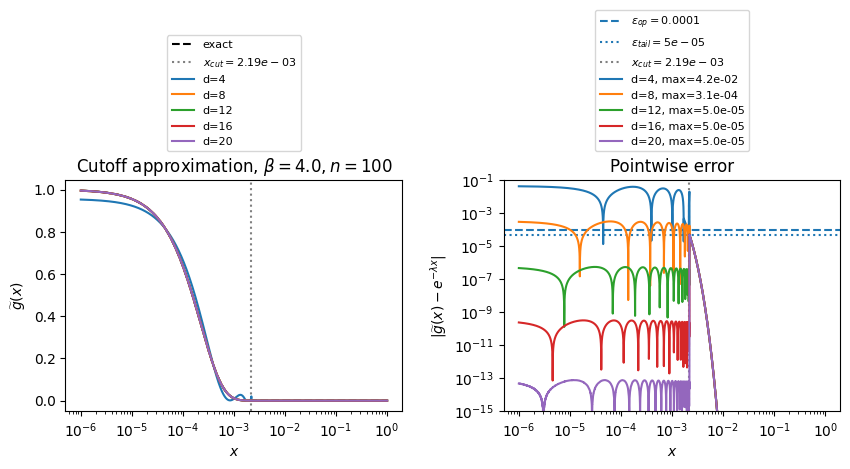

In [7]:
beta = 4
eps_op = 1e-4
n0 = 100

eps_tail = eps_poly = eps_op / 2
degrees = [4, 8, 12, 16, 20]
alpha = lambda n: 2 / np.sqrt(np.pi) * n**1.5  # Worst-case normalization estimate.

def coeffs(tau: float, d: int) -> np.ndarray:
    """Return Chebyshev coefficients for exp(-u) on u in [0, tau]."""
    k = np.arange(d + 1)                       # Chebyshev modes k = 0, ..., d.
    c = 2 * (-1)**k * ive(k, tau / 2)          # Coefficients 2(-1)^k exp(-tau/2) I_k(tau/2).
    c[0] /= 2                                  # The zeroth Chebyshev coefficient has no factor 2.
    return c

def piecewise_exp(x: np.ndarray, lam: float, tau: float, d: int) -> np.ndarray:
    """Return the cutoff Chebyshev approximation to exp(-lam*x)."""
    u = lam * np.maximum(x, 0)                 # Rescaled variable u = lam*x, clipped below at 0.
    p = np.zeros_like(x)                       # Tail region u >= tau is set to zero.
    active = (x > 0) & (u < tau)               # Polynomial is evaluated only before the cutoff.
    p[x <= 0] = 1                              # Metropolis branch is exactly 1 for x <= 0.
    p[active] = chebval(2 * u[active] / tau - 1, coeffs(tau, d))  # Map u in [0, tau] to [-1, 1].
    return np.clip(p, 0, 1)                    # Optional saturation; remove if not implemented.

lam = beta * alpha(n0)
tau = np.log(1 / eps_tail)
x_cut = tau / lam                              # Cutoff point: exp(-lam*x_cut) = eps_tail.

x = np.geomspace(1e-6, 1, 8000)                # Log grid to resolve the cutoff near x = 0.
exact = np.exp(-lam * x)                       # Exact positive-branch function.

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
fig.subplots_adjust(wspace=0.3)

ax[0].plot(x, exact, "k--", label="exact")
ax[1].axhline(eps_op, ls="--", label=fr"$\varepsilon_{{op}}={eps_op}$")
ax[1].axhline(eps_tail, ls=":", label=fr"$\varepsilon_{{tail}}={eps_tail}$")

for a in ax:
    a.axvline(x_cut, ls=":", color="gray", label=fr"$x_{{cut}}={x_cut:.2e}$")

for d in degrees:
    approx = piecewise_exp(x, lam, tau, d)
    err = np.abs(approx - exact)
    ax[0].plot(x, approx, label=f"d={d}")
    ax[1].plot(x, err, label=f"d={d}, max={err.max():.1e}")

for a in ax:
    a.set_xscale("log")
    a.set_xlabel(r"$x$")
    a.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.1))

ax[0].set(title=fr"Cutoff approximation, $\beta={beta:.1f}, n={n0}$", ylabel=r"$\widetilde g(x)$")
ax[1].set(title="Pointwise error", ylabel=r"$|\widetilde g(x)-e^{-\lambda x}|$", yscale="log", ylim=(1e-15, 1e-1))

plt.show()